## MNIST Implementation

100.0%
100.0%
100.0%
100.0%


Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


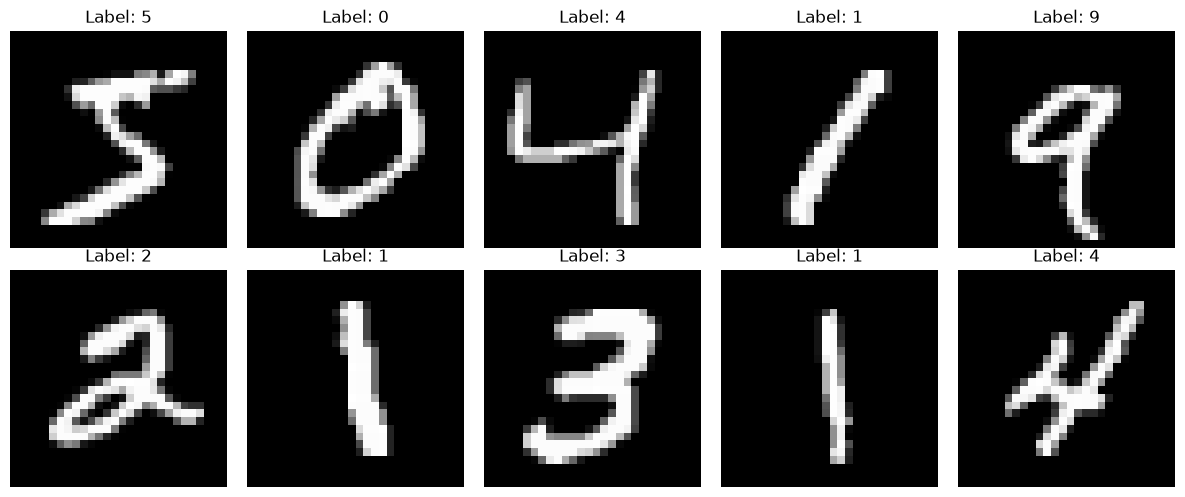

In [ ]:
# importing the libraries and data
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train=True,
                               download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False,
                               transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()


Epoch  1 | Train: 91.66% | Test: 96.11%
Epoch  2 | Train: 96.02% | Test: 97.09%
Epoch  3 | Train: 96.98% | Test: 97.29%
Epoch  4 | Train: 97.45% | Test: 97.55%
Epoch  5 | Train: 97.64% | Test: 97.75%
Epoch  6 | Train: 97.95% | Test: 97.96%
Epoch  7 | Train: 98.14% | Test: 97.95%
Epoch  8 | Train: 98.22% | Test: 98.07%
Epoch  9 | Train: 98.34% | Test: 97.57%
Epoch 10 | Train: 98.48% | Test: 98.16%


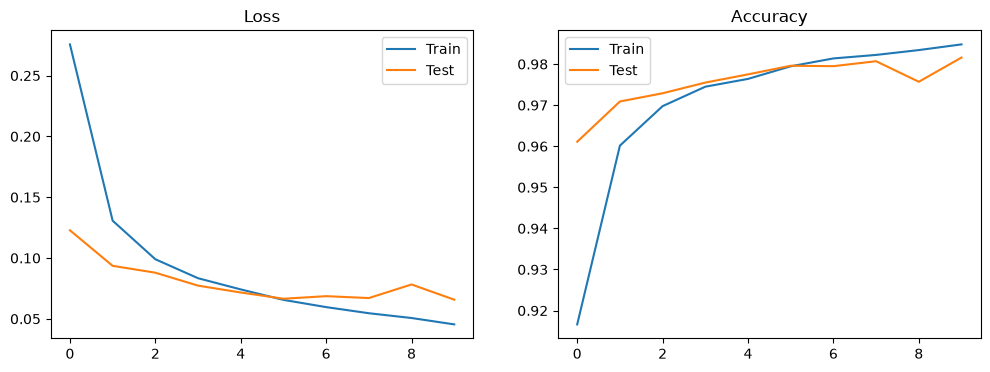

In [ ]:
# network
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),              # it turns 28x28 pixels to 784
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),        # 10 output classes
        )

    def forward(self, x):
        return self.network(x)

model = MNISTNet()
criterion = nn.CrossEntropyLoss()      # multiple classes so no sigmoid is needed
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            correct += (output.argmax(1) == y_batch).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

# training
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(10):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f"Epoch {epoch+1:2d} | Train: {train_acc*100:.2f}% | Test: {test_acc*100:.2f}%")

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='Train')
axes[0].plot(test_losses, label='Test')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(train_accs, label='Train')
axes[1].plot(test_accs, label='Test')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.show()

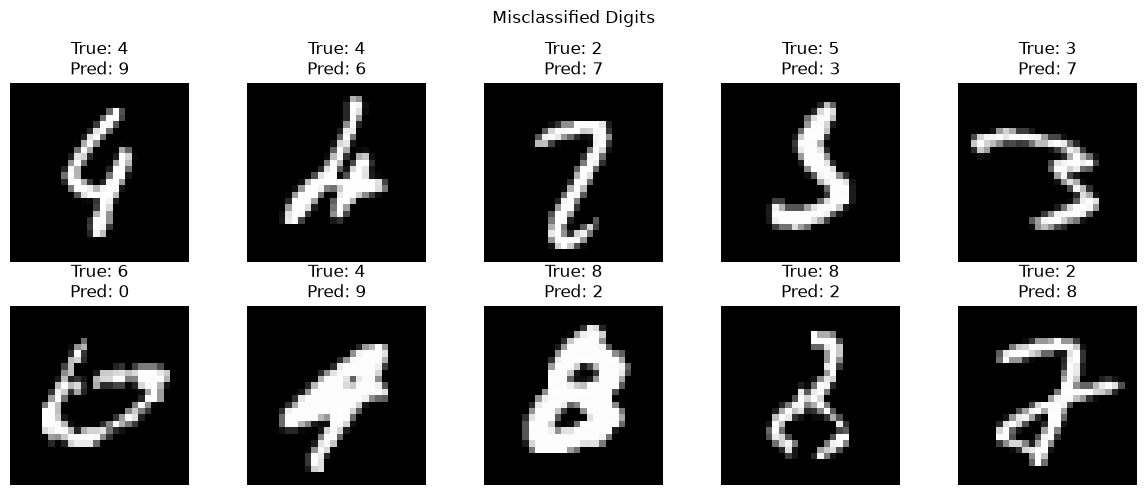

In [ ]:
# evaluation
model.eval()
wrong_images = []
wrong_labels = []
wrong_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        preds = output.argmax(1)
        mask = preds != y_batch
        wrong_images.extend(X_batch[mask])
        wrong_labels.extend(y_batch[mask])
        wrong_preds.extend(preds[mask])
        if len(wrong_images) >= 10:
            break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.set_title(f"True: {wrong_labels[i]}\nPred: {wrong_preds[i]}")
    ax.axis('off')
plt.suptitle('Misclassified Digits')
plt.tight_layout()
plt.show()